# One-Site Association and Dissociation with Induced fit

This notebook simulates one-site binding traces in the case that binding induces a conformational change and plots association+dissociation traces together.

In [72]:
import numpy as np
from pykingenie.utils.signal_surface import (
    solve_induced_fit_association,
    solve_induced_fit_dissociation
)
from pykingenie.utils.plotting import plot_traces
from pykingenie.utils.palettes import VIRIDIS
from notebook_helpers import show_plotly_static

## Parameters

- `kon`: rate constant for E + S -> E·S (1/μM/s)
- `koff`: rate constant for E·S -> E + S (1/s)
- `kc`: rate constant for E·S -> ES (1/s)
- `krev`: rate constant for ES -> E·S (1/s)

- `smax` : Maximum signal that can be achieved

We assume that the signal given by the complex E·S and ES is the same. 
In other words, the complex before and after the conformational change produces the same signal.

Ligand concentrations are log-spaced and traces use a Viridis palette.

In [73]:
kon = 0.5
koff = 0.01
kc = 1
krev = 10

smax = 1

In [74]:
concentrations = np.logspace(-2, 1, 6) # In micromolar
t_assoc = np.linspace(0, 300, 400)
t_disso = np.linspace(0, 300, 400)

colors = [VIRIDIS[int(i)] for i in np.linspace(0, len(VIRIDIS) - 1, len(concentrations))]

In [75]:
combined_xs, combined_ys, legends = [], [], []

for conc in concentrations:

    assoc_matrix = solve_induced_fit_association(
        time = t_assoc, 
        a_conc = conc, 
        kon = kon, 
        koff = koff, 
        kc = kc, 
        krev = krev, 
        sP1L=0, # Initial signal proportional to the concentration of E·S
        sP2L=0, # Initial signal proportional to the concentration of ES
        smax=5
    )

    # assoc matrix returns a numpy array with columns 'signal','sP1L','sP2L'
    y_assoc = assoc_matrix[:, 0]  # Extract the signal column

    sP2L = assoc_matrix[-1, 2]  # Get the last value of sP2L from the association phase

    disso_matrix = solve_induced_fit_dissociation(
        time=t_disso,
        koff=koff,
        kc=kc,
        krev=krev,
        s0=y_assoc[-1],  # Initial signal for dissociation is the last signal from association
        smax=5,
        sP2L=sP2L 
    )

    y_disso = disso_matrix[:, 0]  # Extract the signal column for dissociation

    combined_xs.append([t_assoc, t_disso + t_assoc[-1]])
    combined_ys.append([y_assoc, y_disso])
    legends.append(f"{conc:.3g} μM")

show = [True] * len(concentrations)

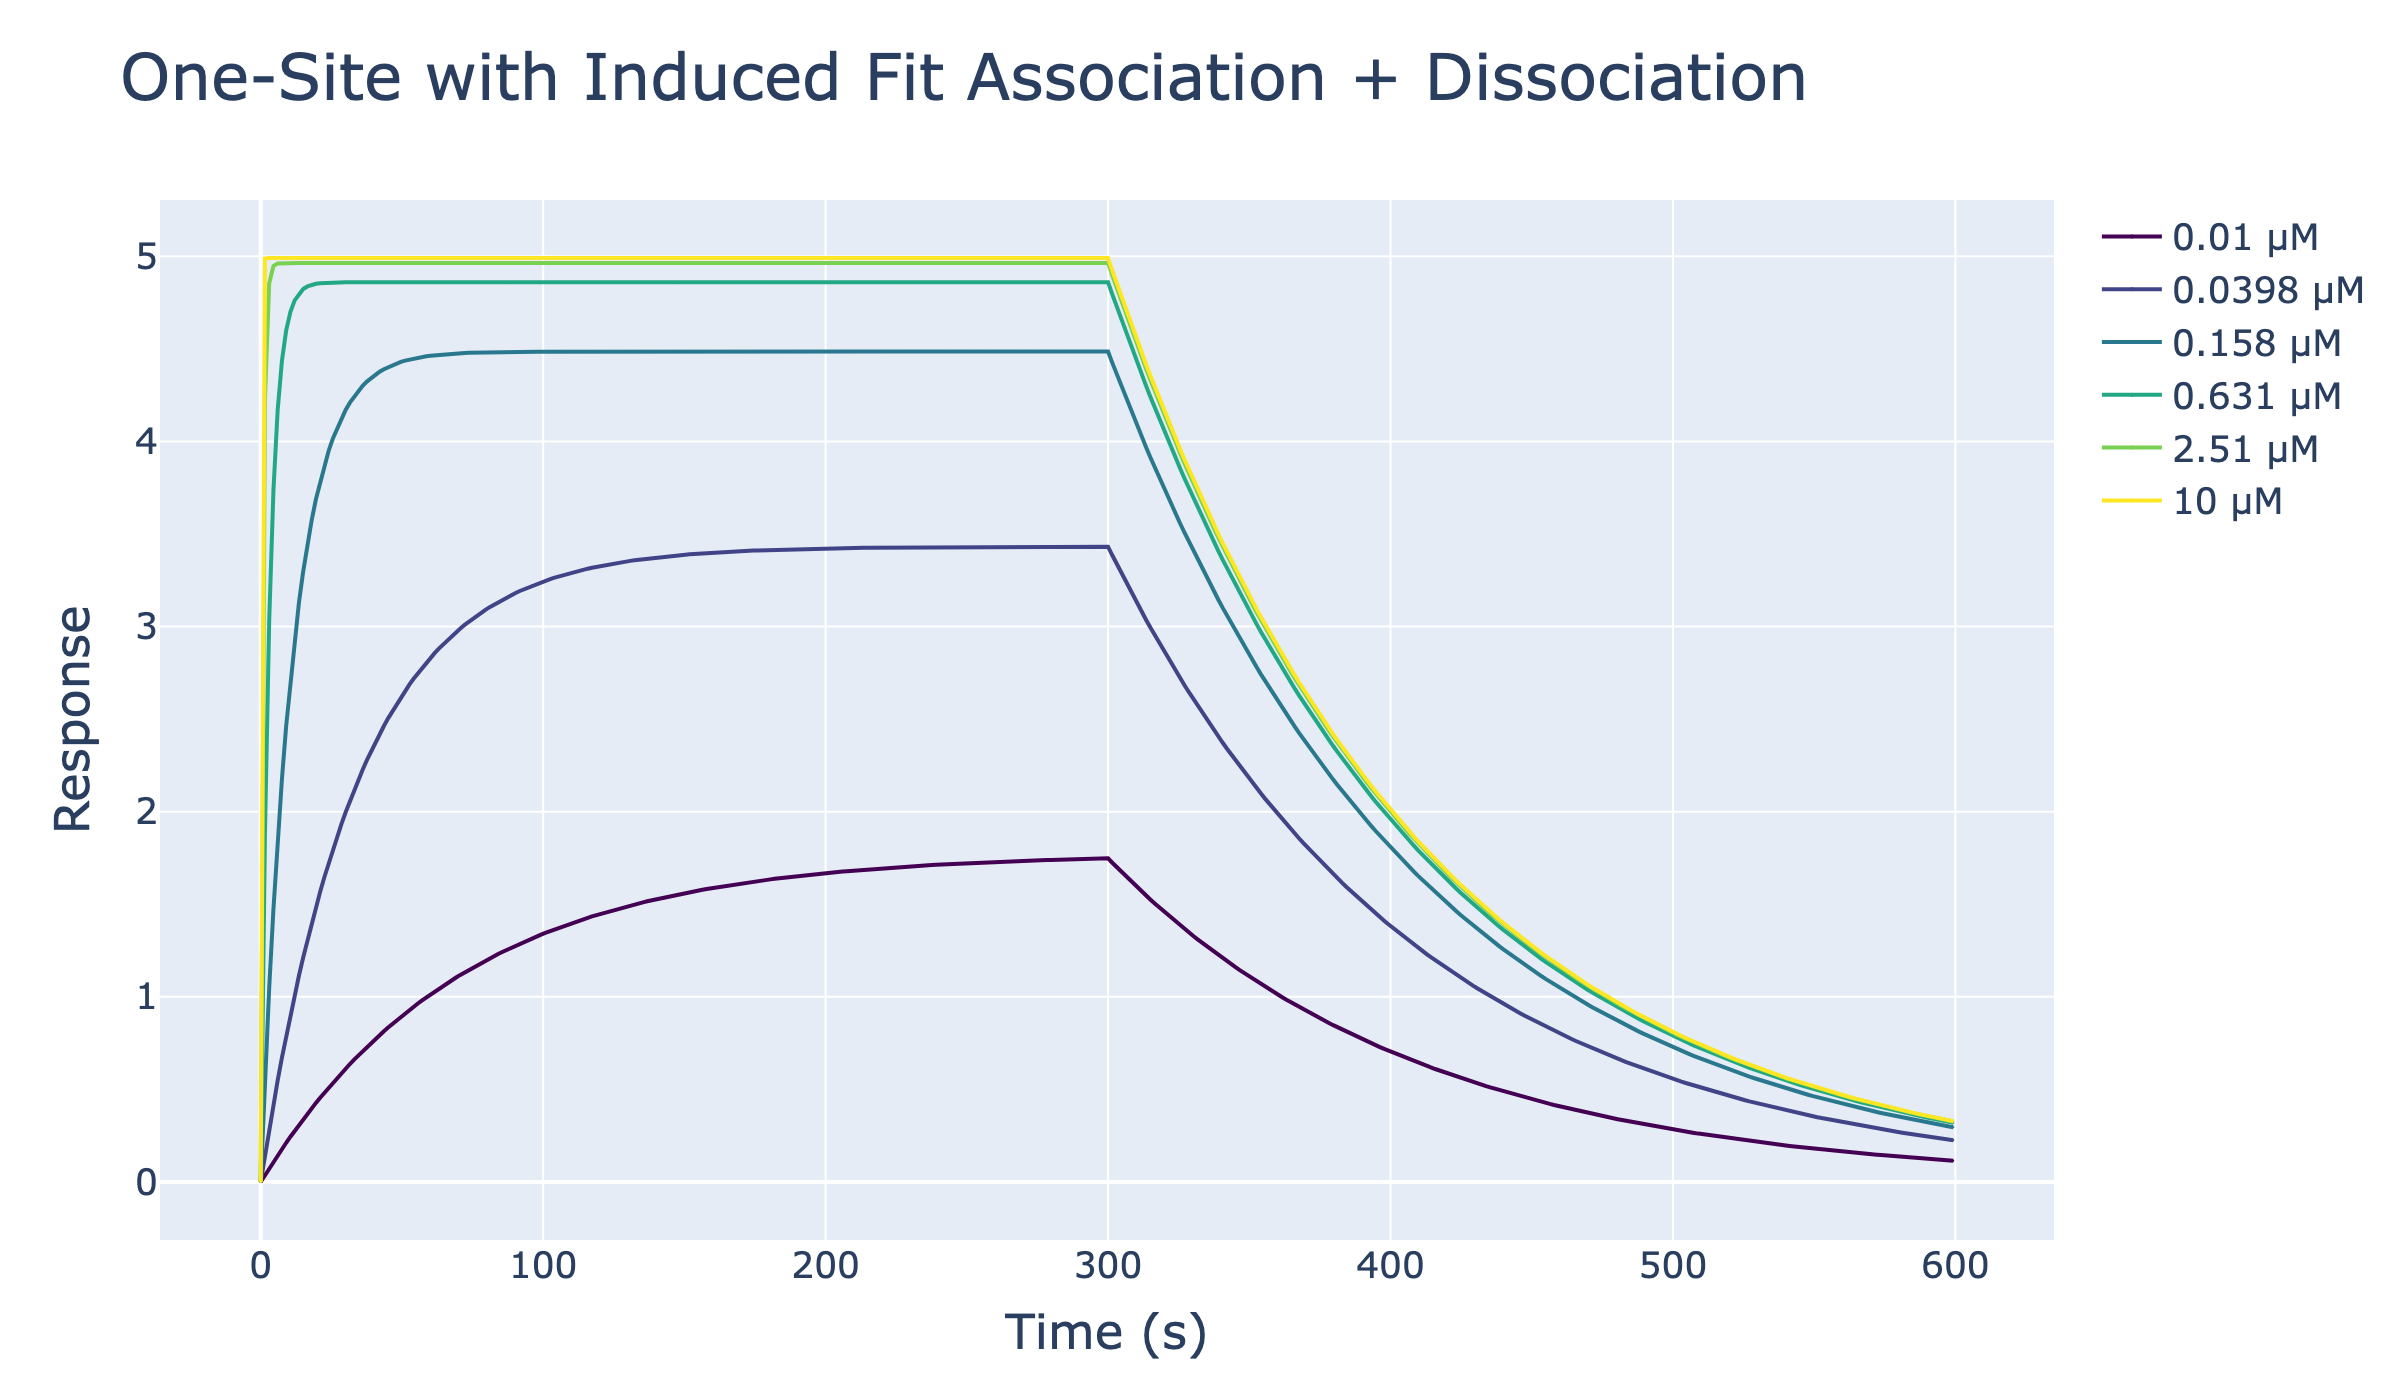

In [76]:
fig = plot_traces(
    xs=combined_xs,
    ys=combined_ys,
    legends=legends,
    colors=colors,
    show=show,
    marker_size=1,
    line_width=2,
)

fig.update_layout(
    title={"text": "One-Site with Induced Fit Association + Dissociation", "font": {"size": 32}},
    xaxis_title="Time (s)",
    yaxis_title="Response",
    font={"size": 20},
    legend={"font": {"size": 18}},
)
fig.update_xaxes(title_font={"size": 24}, tickfont={"size": 18})
fig.update_yaxes(title_font={"size": 24}, tickfont={"size": 18})

show_plotly_static(fig)